[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\OMKAR\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\OMKAR\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\OMKAR\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


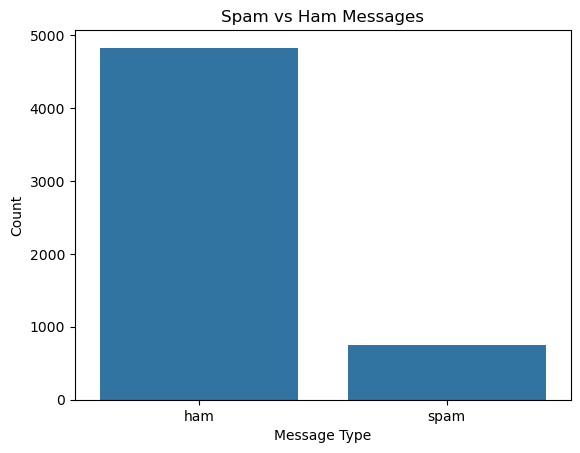

RESULT:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       957
           1       1.00      0.74      0.85       158

    accuracy                           0.96      1115
   macro avg       0.98      0.87      0.91      1115
weighted avg       0.96      0.96      0.96      1115



In [7]:
import pandas as pd
import nltk
nltk.download('punkt_tab')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

import seaborn as sns
import matplotlib.pyplot as plt

# Download nltk data
nltk.download('punkt')
nltk.download('stopwords')

# Load dataset
df = pd.read_csv(r"C:\Users\OMKAR\Desktop\SMSSpamCollection",
                 sep='\t', names=['label','text'])


#  GRAPH (IMPORTANT)

sns.countplot(x='label', data=df)

plt.title("Spam vs Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Count")

plt.show()


#  Convert labels

df['label'] = df['label'].map({'ham':0, 'spam':1})


#  Text cleaning

ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    words = word_tokenize(text)
    words = [w.lower() for w in words if w.isalnum()]
    words = [w for w in words if w not in stop_words]
    words = [ps.stem(w) for w in words]
    return " ".join(words)

df['clean'] = df['text'].apply(clean_text)


#  TF-IDF

tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df['clean'])
y = df['label']


#  Split data

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


#  Model

model = MultinomialNB()
model.fit(X_train, y_train)


#  Prediction

y_pred = model.predict(X_test)

print("RESULT:\n")
print(classification_report(y_test, y_pred))